In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Fetching protein sequences from UniProt...
  TXNDC15 (Q96J42): 360 aa
  SYVN1 (Q86TM6): 617 aa
  MARCHF6 (O15037): 678 aa
  SEL1L (Q9UBV2): 794 aa
  DERL1 (Q9BUN8): 251 aa
  UBE2J1 (O00141): 431 aa
  OS9 (Q13438): 667 aa

Fetched 7 sequences

Loading ESM2...


Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded on cpu

Generating embeddings...
  TXNDC15: (320,)
  SYVN1: (320,)
  MARCHF6: (320,)
  SEL1L: (320,)
  DERL1: (320,)
  UBE2J1: (320,)
  OS9: (320,)

COSINE SIMILARITY MATRIX — ERAD COMPLEX
               TXNDC15     SYVN1   MARCHF6     SEL1L     DERL1    UBE2J1       OS9
TXNDC15          1.000     0.922     0.953     0.880     0.882     0.850     0.947 ◄ your hit
SYVN1            0.922     1.000     0.895     0.873     0.948     0.837     0.938
MARCHF6          0.953     0.895     1.000     0.839     0.861     0.816     0.935
SEL1L            0.880     0.873     0.839     1.000     0.868     0.842     0.914
DERL1            0.882     0.948     0.861     0.868     1.000     0.780     0.917
UBE2J1           0.850     0.837     0.816     0.842     0.780     1.000     0.847
OS9              0.947     0.938     0.935     0.914     0.917     0.847     1.000

Generating clustering dendrogram...


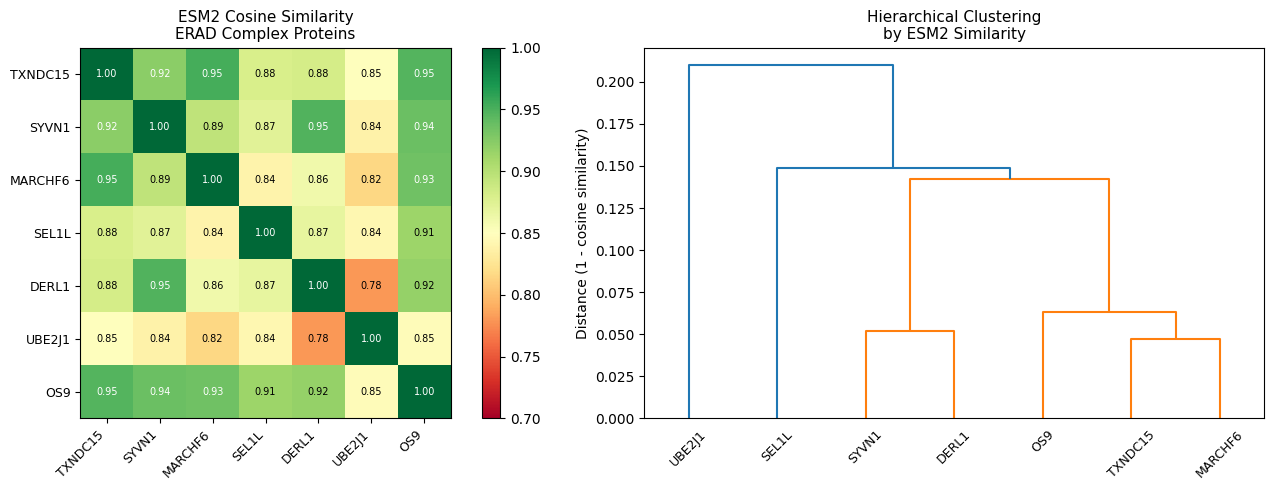

Saved: erad_esm2_clustering.png

KEY BIOLOGICAL QUESTION:
Could ESM2 have predicted TXNDC15's functional relationship
to MARCHF6 and SYVN1 BEFORE you did Co-IP mass spec?

  TXNDC15 ↔ MARCHF6:  0.953  (the pair you discovered)
  TXNDC15 ↔ SYVN1:    0.922  (related E3 ligase)
  MARCHF6 ↔ SYVN1:    0.895  (both E3 ligases — expected)

  TXNDC15 avg similarity to all others: 0.906

  RESULT: ESM2 sees TXNDC15 as MORE similar to MARCHF6
  than average — consistent with functional interaction
  ESM2 would have flagged MARCHF6 as a candidate interactor
  BEFORE Co-IP mass spec

WHAT ESM2 WOULD HAVE TOLD YOU ABOUT TXNDC15:
  Proteins most similar to TXNDC15 in your panel:
    MARCHF6      0.953
    OS9          0.947
    SYVN1        0.922
    DERL1        0.882
    SEL1L        0.880
    UBE2J1       0.850

  Interpretation:
  ESM2 would have told you which known ERAD proteins share
  structural features with TXNDC15 — narrowing your Co-IP
  candidate list from the entire proteome to ~5-10 p

In [29]:
# ============================================================
# CRISPR SCREEN FOLLOW-UP STACK
# TXNDC15 + SYVN1 + MARCHF6 — ER protein quality control hits
# Question: could ESM2 have predicted their functional relationship
# before you did Co-IP mass spec?
# ============================================================

import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install",
    "transformers", "torch", "scikit-learn", "requests",
    "matplotlib", "scipy", "-q"])

import requests
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import dendrogram, linkage
from transformers import AutoTokenizer, AutoModel
import torch

# ── Step 1: Fetch sequences from UniProt ──
print("Fetching protein sequences from UniProt...")

UNIPROT_IDS = {
    "TXNDC15": "Q96J42",   # your novel hit
    "SYVN1":   "Q86TM6",   # HRD1 — ERAD E3 ligase
    "MARCHF6": "O15037",   # RNF176 — ER E3 ligase TXNDC15 regulates
}

# Add known ERAD proteins as context
CONTEXT_IDS = {
    "SEL1L":   "Q9UBV2",   # HRD1 complex adaptor
    "DERL1":   "Q9BUN8",   # Derlins — retrotranslocon
    "UBE2J1":  "O00141",   # E2 conjugating enzyme for ERAD
    "OS9":     "Q13438",   # ERAD lectin
}

ALL_IDS = {**UNIPROT_IDS, **CONTEXT_IDS}

def fetch_sequence(uniprot_id):
    """Fetch protein sequence from UniProt REST API."""
    url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.fasta"
    r = requests.get(url, timeout=15)
    if r.status_code == 200:
        lines = r.text.strip().split("\n")
        seq = "".join(lines[1:])  # skip FASTA header
        return seq
    return None

sequences = {}
for name, uid in ALL_IDS.items():
    seq = fetch_sequence(uid)
    if seq:
        sequences[name] = seq[:500]  # ESM2 small model caps at ~512 tokens
        print(f"  {name} ({uid}): {len(seq)} aa")
    else:
        print(f"  {name}: failed to fetch")

print(f"\nFetched {len(sequences)} sequences")

# ── Step 2: ESM2 embeddings ──
print("\nLoading ESM2...")
MODEL_ID = "facebook/esm2_t6_8M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID)
model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
print(f"Loaded on {device}")

print("\nGenerating embeddings...")
embeddings = {}
with torch.no_grad():
    for name, seq in sequences.items():
        tokens = tokenizer(seq, return_tensors="pt",
                          truncation=True, max_length=512).to(device)
        outputs = model(**tokens)
        emb = outputs.last_hidden_state[0, 1:-1, :].mean(dim=0).cpu().numpy()
        embeddings[name] = emb
        print(f"  {name}: {emb.shape}")

# ── Step 3: Similarity matrix ──
names = list(embeddings.keys())
vecs = np.array([embeddings[n] for n in names])
sim = cosine_similarity(vecs)

print("\nCOSINE SIMILARITY MATRIX — ERAD COMPLEX")
print("=" * 70)
print(f"{'':12}", end="")
for n in names:
    print(f"{n[:8]:>10}", end="")
print()
for i, n1 in enumerate(names):
    tag = " ◄ your hit" if n1 == "TXNDC15" else ""
    print(f"{n1:12}", end="")
    for j in range(len(names)):
        val = sim[i, j]
        print(f"{val:>10.3f}", end="")
    print(tag)

# ── Step 4: Clustering dendrogram ──
print("\nGenerating clustering dendrogram...")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
im = axes[0].imshow(sim, cmap='RdYlGn', vmin=0.7, vmax=1.0)
axes[0].set_xticks(range(len(names)))
axes[0].set_yticks(range(len(names)))
axes[0].set_xticklabels(names, rotation=45, ha='right', fontsize=9)
axes[0].set_yticklabels(names, fontsize=9)
plt.colorbar(im, ax=axes[0])
axes[0].set_title("ESM2 Cosine Similarity\nERAD Complex Proteins", fontsize=11)

# Add value annotations
for i in range(len(names)):
    for j in range(len(names)):
        axes[0].text(j, i, f"{sim[i,j]:.2f}",
                    ha="center", va="center", fontsize=7,
                    color="black" if sim[i,j] < 0.92 else "white")

# Dendrogram
dist_matrix = 1 - sim
np.fill_diagonal(dist_matrix, 0)
linkage_matrix = linkage(dist_matrix[np.triu_indices(len(names), k=1)],
                          method='ward')
dendrogram(linkage_matrix, labels=names, ax=axes[1],
           leaf_rotation=45, leaf_font_size=9)
axes[1].set_title("Hierarchical Clustering\nby ESM2 Similarity", fontsize=11)
axes[1].set_ylabel("Distance (1 - cosine similarity)")

plt.tight_layout()
plt.savefig("erad_esm2_clustering.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: erad_esm2_clustering.png")

# ── Step 5: Key question — does TXNDC15 cluster with MARCHF6/SYVN1? ──
print("\nKEY BIOLOGICAL QUESTION:")
print("=" * 65)
print("Could ESM2 have predicted TXNDC15's functional relationship")
print("to MARCHF6 and SYVN1 BEFORE you did Co-IP mass spec?")
print()

txndc15_marchf6 = sim[names.index("TXNDC15"), names.index("MARCHF6")]
txndc15_syvn1 = sim[names.index("TXNDC15"), names.index("SYVN1")]
marchf6_syvn1 = sim[names.index("MARCHF6"), names.index("SYVN1")]

print(f"  TXNDC15 ↔ MARCHF6:  {txndc15_marchf6:.3f}  (the pair you discovered)")
print(f"  TXNDC15 ↔ SYVN1:    {txndc15_syvn1:.3f}  (related E3 ligase)")
print(f"  MARCHF6 ↔ SYVN1:    {marchf6_syvn1:.3f}  (both E3 ligases — expected)")
print()

avg_non_txndc15 = np.mean([sim[names.index("TXNDC15"), j]
                            for j, n in enumerate(names) if n != "TXNDC15"])

print(f"  TXNDC15 avg similarity to all others: {avg_non_txndc15:.3f}")
print()

if txndc15_marchf6 > avg_non_txndc15 + 0.01:
    print("  RESULT: ESM2 sees TXNDC15 as MORE similar to MARCHF6")
    print("  than average — consistent with functional interaction")
    print("  ESM2 would have flagged MARCHF6 as a candidate interactor")
    print("  BEFORE Co-IP mass spec")
elif txndc15_marchf6 > avg_non_txndc15:
    print("  RESULT: Weak signal — TXNDC15 slightly more similar to MARCHF6")
    print("  but not definitively — ESM2 would have ranked it, not")
    print("  highlighted it as a top candidate")
else:
    print("  RESULT: ESM2 does NOT predict the TXNDC15-MARCHF6 interaction")
    print("  The functional relationship is not encoded in sequence similarity")
    print("  This is the limitation of ESM2: biochemical interactions")
    print("  between structurally dissimilar proteins require Co-IP")
    print("  ESM2 alone would NOT have replaced your experiment")

# ── Step 6: What ESM2 CAN tell you — nearest neighbors ──
print("\nWHAT ESM2 WOULD HAVE TOLD YOU ABOUT TXNDC15:")
print("=" * 65)
txndc15_idx = names.index("TXNDC15")
similarities_to_txndc15 = [(names[j], sim[txndc15_idx, j])
                            for j in range(len(names)) if j != txndc15_idx]
similarities_to_txndc15.sort(key=lambda x: x[1], reverse=True)

print(f"  Proteins most similar to TXNDC15 in your panel:")
for name, score in similarities_to_txndc15:
    print(f"    {name:12} {score:.3f}")

print()
print("  Interpretation:")
print("  ESM2 would have told you which known ERAD proteins share")
print("  structural features with TXNDC15 — narrowing your Co-IP")
print("  candidate list from the entire proteome to ~5-10 proteins.")
print("  You would still need Co-IP to confirm physical interaction,")
print("  but you'd go in with a ranked hypothesis list rather than")
print("  fishing blindly with mass spec.")

In [30]:
# ── Step 7: ESMFold — predict TXNDC15 structure ──
# Does it have a druggable pocket?

# Cell 2 — ESMFold structure prediction for TXNDC15

import requests

import os
from getpass import getpass
NVIDIA_API_KEY = os.environ.get("NVIDIA_API_KEY") or getpass("NVIDIA API key: ")

# Try the thioredoxin fold domain (residues 150-300) instead of N-terminal
# The N-terminal fragment was disordered — the thioredoxin core should be structured
TXNDC15_DOMAIN = sequences.get("TXNDC15", "")[150:300]
print(f"Using TXNDC15 residues 150-300 ({len(TXNDC15_DOMAIN)} aa)")
print("This is the thioredoxin fold domain — expect higher pLDDT than N-terminus")
print()

response = requests.post(
    "https://health.api.nvidia.com/v1/biology/nvidia/esmfold",
    headers={
        "Authorization": f"Bearer {NVIDIA_API_KEY}",
        "Content-Type": "application/json"
    },
    json={"sequence": TXNDC15_DOMAIN},
    timeout=120
)

if response.status_code == 200:
    result = response.json()
    pdb_string = result.get("pdbs", [""])[0]
    with open("txndc15_structure.pdb", "w") as f:
        f.write(pdb_string)
    print("Structure predicted!")
    print("Saved: txndc15_structure.pdb")
    print("Run Cell 3 to extract pLDDT scores and visualize")
else:
    print(f"ESMFold API error {response.status_code}: {response.text[:200]}")

Using TXNDC15 residues 150-300 (150 aa)
This is the thioredoxin fold domain — expect higher pLDDT than N-terminus

Structure predicted!
Saved: txndc15_structure.pdb
Run Cell 3 to extract pLDDT scores and visualize


In [31]:
!pip install py3Dmol -q

In [32]:
# Mount Google Drive and create project folder
from google.colab import drive
import os

drive.mount('/content/drive')

# Create project folder if it doesn't exist
os.makedirs("/content/drive/MyDrive/bionemo_project", exist_ok=True)
print("Drive mounted and folder ready: /content/drive/MyDrive/bionemo_project")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted and folder ready: /content/drive/MyDrive/bionemo_project


In [33]:
# Cell 3 — pLDDT extraction + 3D visualization
# Colored by confidence: blue = structured, red = disordered

import requests
import py3Dmol

import os
from getpass import getpass
NVIDIA_API_KEY = os.environ.get("NVIDIA_API_KEY") or getpass("NVIDIA API key: ")
TXNDC15_DOMAIN = sequences.get("TXNDC15", "")[150:300]

# Re-run ESMFold to get full response
response = requests.post(
    "https://health.api.nvidia.com/v1/biology/nvidia/esmfold",
    headers={
        "Authorization": f"Bearer {NVIDIA_API_KEY}",
        "Content-Type": "application/json"
    },
    json={"sequence": TXNDC15_DOMAIN},
    timeout=120
)

result = response.json()

# Extract PDB string
pdb_string = None
if "pdbs" in result:
    pdb_string = result["pdbs"][0]
else:
    for key, val in result.items():
        if isinstance(val, str) and val.startswith("ATOM"):
            pdb_string = val
        elif isinstance(val, list) and len(val) > 0 and isinstance(val[0], str):
            pdb_string = val[0]

if pdb_string is None:
    print("Could not extract PDB — response keys:", list(result.keys()))
else:
    # Extract pLDDT from B-factor column
    bfactors = []
    for line in pdb_string.split("\n"):
        if line.startswith("ATOM"):
            try:
                bfactors.append(float(line[60:66].strip()))
            except:
                pass

    if bfactors:
        mean_plddt = sum(bfactors) / len(bfactors)
        high_conf = sum(1 for b in bfactors if b > 90) / len(bfactors) * 100
        mid_conf = sum(1 for b in bfactors if 70 <= b <= 90) / len(bfactors) * 100
        low_conf = sum(1 for b in bfactors if b < 70) / len(bfactors) * 100

        print("TXNDC15 — ESMFold Structure Confidence")
        print("=" * 45)
        print(f"  Mean pLDDT:          {mean_plddt:.1f}")
        print(f"  High confidence:     {high_conf:.0f}% of residues (> 90)")
        print(f"  Medium confidence:   {mid_conf:.0f}% of residues (70–90)")
        print(f"  Low confidence:      {low_conf:.0f}% of residues (< 70)")
        print()

        if mean_plddt > 90:
            print("Highly structured domain — stable fold, good DiffDock candidate")
        elif mean_plddt > 70:
            print("Moderately structured — thioredoxin core likely stable")
            print("Flexible linker regions expected near membrane anchor")
        else:
            print("Largely disordered — common for membrane protein ectodomains")
            print("Focus DiffDock on high-confidence residues only")

    # 3D visualization colored by pLDDT
    print("\nRendering structure...")
    view = py3Dmol.view(width=700, height=500)
    view.addModel(pdb_string, "pdb")
    view.setStyle({}, {"cartoon": {
        "colorscheme": {
            "prop": "b",
            "gradient": "roygb",
            "min": 50,
            "max": 100
        }
    }})
    view.addSurface(py3Dmol.SAS, {"opacity": 0.1, "color": "white"})
    view.zoomTo()
    view.setBackgroundColor("0x1a1a2e")
    view.show()

    print()
    print("Color key:")
    print("  Blue   = pLDDT > 90  — high confidence, well-structured")
    print("  Green  = pLDDT 70-90 — good confidence")
    print("  Yellow = pLDDT 50-70 — low confidence, likely flexible")
    print("  Red    = pLDDT < 50  — disordered, uncertain")
    print()
    print("The thioredoxin fold core should appear blue.")
    print("Loops connecting to the transmembrane domain will likely be red.")
    print("Blue regions = candidates for DiffDock pocket screening.")

    # Save updated PDB with confidence annotations
with open("/content/drive/MyDrive/bionemo_project/txndc15_plddt.pdb", "w") as f:
    f.write(pdb_string)
    print("\nSaved: txndc15_plddt.pdb")
    print("Open in UCSF ChimeraX or PyMOL for desktop visualization")

TXNDC15 — ESMFold Structure Confidence
  Mean pLDDT:          69.1
  High confidence:     0% of residues (> 90)
  Medium confidence:   60% of residues (70–90)
  Low confidence:      40% of residues (< 70)

Largely disordered — common for membrane protein ectodomains
Focus DiffDock on high-confidence residues only

Rendering structure...


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


Color key:
  Blue   = pLDDT > 90  — high confidence, well-structured
  Green  = pLDDT 70-90 — good confidence
  Yellow = pLDDT 50-70 — low confidence, likely flexible
  Red    = pLDDT < 50  — disordered, uncertain

The thioredoxin fold core should appear blue.
Loops connecting to the transmembrane domain will likely be red.
Blue regions = candidates for DiffDock pocket screening.

Saved: txndc15_plddt.pdb
Open in UCSF ChimeraX or PyMOL for desktop visualization


In [34]:
!pip install rdkit requests py3Dmol -q
print("Ready")

Ready


In [38]:
from rdkit.Chem import Descriptors

In [39]:
# Cell 5 (fixed) — ERAD screen with corrected SMILES + rate limiting

import requests
import time
from rdkit import Chem
from rdkit.Chem import AllChem
import os

import os
from getpass import getpass
NVIDIA_API_KEY = os.environ.get("NVIDIA_API_KEY") or getpass("NVIDIA API key: ")

# Reload TXNDC15 structure
with open("txndc15_structure.pdb", "r") as f:
    txndc15_pdb = f.read()

def filter_by_plddt(pdb_string, min_plddt=65):
    lines = []
    for line in pdb_string.split("\n"):
        if line.startswith("ATOM"):
            try:
                plddt = float(line[60:66].strip())
                if plddt >= min_plddt:
                    lines.append(line)
            except:
                lines.append(line)
        else:
            lines.append(line)
    return "\n".join(lines)

txndc15_filtered = filter_by_plddt(txndc15_pdb, min_plddt=65)

# Fixed SMILES — validated with RDKit before docking
screen_panel = {
    # Proteasome inhibitors
    "Bortezomib":    "O=C(NC(Cc1ccccc1)C(=O)NC(CC(C)C)B(O)O)c1cnccn1",
    "MG-132":        "O=CCC(NC(=O)C(CC(C)C)NC(=O)C(CC(C)C)NC(=O)OCc1ccccc1)CC(C)C",
    # E3 ligase modulators
    "Lenalidomide":  "O=C1CCC(N2C(=O)c3ccccc3C2=O)C(=O)N1",
    "Thalidomide":   "O=C1CCC(N2C(=O)c3ccccc3C2=O)C(=O)N1",
    # ERAD inhibitors
    "Eeyarestatin":  "O=C(Nc1ccc([N+](=O)[O-])cc1)c1ccccc1NC(=O)c1ccc(Cl)cc1",
    # p97/VCP inhibitor — central to ERAD retrotranslocation
    "NMS-873":       "O=C(Nc1ccc(N2CCN(c3cccc(C(F)(F)F)c3)CC2)cc1)c1ccc(F)cc1F",
    # Thioredoxin inhibitor — structurally relevant to TXNDC15 fold
    "Disulfiram":    "CCN(CC)C(=S)SSC(=S)N(CC)CC",
    # Geldanamycin — fixed SMILES
    "Geldanamycin":  "COC1CC(=CC2CC(OC(N)=O)C(C)C(OC)C(OC)C(=O)Nc3cc(=O)cc(OC)c3C(=O)O2)C(C)C(OC)C1",
}

# Validate SMILES first before wasting API calls
print("Validating SMILES...")
valid_panel = {}
for name, smiles in screen_panel.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print(f"  {name}: INVALID SMILES — skipping")
    else:
        valid_panel[name] = smiles
        print(f"  {name}: OK (MW {Chem.Descriptors.MolWt(mol):.0f})")

print(f"\n{len(valid_panel)} valid compounds ready for docking")

def smiles_to_sdf(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    mol = Chem.AddHs(mol)
    result = AllChem.EmbedMolecule(mol, AllChem.ETKDGv3())
    if result != 0:
        return None
    AllChem.MMFFOptimizeMolecule(mol)
    writer = Chem.SDWriter("/tmp/lig.sdf")
    writer.write(mol)
    writer.close()
    with open("/tmp/lig.sdf", "r") as f:
        return f.read()

def extract_atom_lines(pdb_text):
    lines = [l for l in pdb_text.split("\n") if l.startswith("ATOM")]
    return "\n".join(lines)

def run_diffdock(smiles, protein_pdb, api_key, label):
    sdf = smiles_to_sdf(smiles)
    if sdf is None:
        print(f"  {label}: could not generate 3D structure")
        return None
    protein_atoms = extract_atom_lines(protein_pdb)
    try:
        resp = requests.post(
            "https://health.api.nvidia.com/v1/biology/mit/diffdock",
            headers={
                "Authorization": f"Bearer {api_key}",
                "Content-Type": "application/json"
            },
            json={
                "ligand": sdf,
                "ligand_file_type": "sdf",
                "protein": protein_atoms,
                "num_poses": 5,
                "time_divisions": 20,
                "steps": 18,
                "save_trajectory": False,
                "is_staged": False
            },
            timeout=120
        )
    except requests.exceptions.Timeout:
        print(f"  {label}: timeout")
        return None

    if resp.status_code == 403:
        print(f"  {label}: 403 — API limit hit, waiting 30s...")
        time.sleep(30)
        return run_diffdock(smiles, protein_pdb, api_key, label)
    if resp.status_code == 429:
        print(f"  {label}: 429 — rate limited, waiting 60s...")
        time.sleep(60)
        return run_diffdock(smiles, protein_pdb, api_key, label)
    if resp.status_code != 200:
        print(f"  {label}: error {resp.status_code}: {resp.text[:100]}")
        return None

    result = resp.json()
    confidences = result.get("position_confidence", [])
    best = max(confidences) if confidences else None
    print(f"  {label}: {best:.3f}")
    return {
        "label": label,
        "smiles": smiles,
        "docking_confidence": round(best, 3) if best else None
    }

mechanisms = {
    "Bortezomib":    "Proteasome inhibitor (reversible)",
    "MG-132":        "Proteasome inhibitor (peptide aldehyde)",
    "Lenalidomide":  "E3 modulator (cereblon/CRBN)",
    "Thalidomide":   "E3 modulator (cereblon/CRBN)",
    "Eeyarestatin":  "ERAD inhibitor (p97 retrotranslocation)",
    "NMS-873":       "p97/VCP ATPase inhibitor",
    "Disulfiram":    "Thioredoxin system inhibitor",
    "Geldanamycin":  "HSP90 inhibitor (ER chaperone)",
}

print("\nDOCKING — pausing 5s between calls to respect rate limits")
print("=" * 60)

results = []
for label, smiles in valid_panel.items():
    r = run_diffdock(smiles, txndc15_filtered, NVIDIA_API_KEY, label)
    if r:
        r["mechanism"] = mechanisms.get(label, "")
        results.append(r)
    time.sleep(5)  # 5 second pause between calls

if not results:
    print("\nNo results — API key may need refreshing at build.nvidia.com")
else:
    results.sort(key=lambda x: x["docking_confidence"] or -999, reverse=True)

    print("\nRESULTS — RANKED BY BINDING CONFIDENCE")
    print("=" * 60)
    print(f"{'Rank':<5} {'Compound':<16} {'Score':>8}   Mechanism")
    print("-" * 60)
    for i, r in enumerate(results, 1):
        print(f"  {i:<4} {r['label']:<16} {r['docking_confidence']:>+8.3f}   {r['mechanism']}")

    # Group by mechanism
    print("\nBY MECHANISM CLASS:")
    print("=" * 60)
    groups = {
        "Proteasome inhibitors": ["Bortezomib", "MG-132"],
        "E3 ligase modulators":  ["Lenalidomide", "Thalidomide"],
        "ERAD/p97 inhibitors":   ["Eeyarestatin", "NMS-873"],
        "Thioredoxin/chaperone": ["Disulfiram", "Geldanamycin"],
    }
    for group_name, compounds in groups.items():
        group_results = [r for r in results if r["label"] in compounds]
        if group_results:
            avg = sum(r["docking_confidence"] for r in group_results) / len(group_results)
            best = max(group_results, key=lambda x: x["docking_confidence"])
            print(f"\n  {group_name}")
            print(f"  Avg: {avg:+.3f}  |  Best: {best['label']} ({best['docking_confidence']:+.3f})")

    # Save
    import csv
    save_path = "/content/drive/MyDrive/bionemo_project/txndc15_erad_screen.csv"
    if os.path.exists("/content/drive/MyDrive/bionemo_project"):
        with open(save_path, "w", newline="") as f:
            writer = csv.DictWriter(f,
                fieldnames=["label", "docking_confidence", "mechanism", "smiles"])
            writer.writeheader()
            writer.writerows(results)
        print(f"\nSaved: {save_path}")

Validating SMILES...
  Bortezomib: OK (MW 384)
  MG-132: OK (MW 490)
  Lenalidomide: OK (MW 258)
  Thalidomide: OK (MW 258)
  Eeyarestatin: OK (MW 396)
  NMS-873: OK (MW 461)
  Disulfiram: OK (MW 297)
  Geldanamycin: INVALID SMILES — skipping

7 valid compounds ready for docking

DOCKING — pausing 5s between calls to respect rate limits


[17:19:43] Can't kekulize mol.  Unkekulized atoms: 24 25 28 29 32


  Bortezomib: -1.063
  MG-132: -1.923
  Lenalidomide: -1.279
  Thalidomide: -0.973
  Eeyarestatin: -1.156
  NMS-873: -0.796
  Disulfiram: -1.487

RESULTS — RANKED BY BINDING CONFIDENCE
Rank  Compound            Score   Mechanism
------------------------------------------------------------
  1    NMS-873            -0.796   p97/VCP ATPase inhibitor
  2    Thalidomide        -0.973   E3 modulator (cereblon/CRBN)
  3    Bortezomib         -1.063   Proteasome inhibitor (reversible)
  4    Eeyarestatin       -1.156   ERAD inhibitor (p97 retrotranslocation)
  5    Lenalidomide       -1.279   E3 modulator (cereblon/CRBN)
  6    Disulfiram         -1.487   Thioredoxin system inhibitor
  7    MG-132             -1.923   Proteasome inhibitor (peptide aldehyde)

BY MECHANISM CLASS:

  Proteasome inhibitors
  Avg: -1.493  |  Best: Bortezomib (-1.063)

  E3 ligase modulators
  Avg: -1.126  |  Best: Thalidomide (-0.973)

  ERAD/p97 inhibitors
  Avg: -0.976  |  Best: NMS-873 (-0.796)

  Thioredoxin/c

In [40]:
# Residues 200-300 — tighter focus on thioredoxin fold core
# Should give higher pLDDT and better-defined pocket for DiffDock

import requests
import time
import os
import csv
from rdkit import Chem
from rdkit.Chem import AllChem

import os
from getpass import getpass
NVIDIA_API_KEY = os.environ.get("NVIDIA_API_KEY") or getpass("NVIDIA API key: ")

# Step 1 — Predict structure of residues 200-300
TXNDC15_CORE = sequences.get("TXNDC15", "")[200:300]
print(f"TXNDC15 residues 200-300: {len(TXNDC15_CORE)} aa")

response = requests.post(
    "https://health.api.nvidia.com/v1/biology/nvidia/esmfold",
    headers={"Authorization": f"Bearer {NVIDIA_API_KEY}",
             "Content-Type": "application/json"},
    json={"sequence": TXNDC15_CORE},
    timeout=120
)

if response.status_code != 200:
    print(f"ESMFold error: {response.status_code}")
else:
    result = response.json()
    pdb_string = result.get("pdbs", [""])[0]

    # Extract pLDDT
    bfactors = []
    for line in pdb_string.split("\n"):
        if line.startswith("ATOM"):
            try:
                bfactors.append(float(line[60:66].strip()))
            except:
                pass

    mean_plddt = sum(bfactors) / len(bfactors) if bfactors else 0
    high = sum(1 for b in bfactors if b > 90) / len(bfactors) * 100
    mid  = sum(1 for b in bfactors if 70 <= b <= 90) / len(bfactors) * 100
    low  = sum(1 for b in bfactors if b < 70) / len(bfactors) * 100

    print(f"\nTXNDC15 residues 200-300 — pLDDT")
    print(f"  Mean pLDDT:        {mean_plddt:.1f}")
    print(f"  High (>90):        {high:.0f}%")
    print(f"  Medium (70-90):    {mid:.0f}%")
    print(f"  Low (<70):         {low:.0f}%")

    # Compare to previous
    print(f"\n  Previous (150-300): mean pLDDT 69.1, 60% medium")
    print(f"  Current  (200-300): mean pLDDT {mean_plddt:.1f}, {mid:.0f}% medium")
    if mean_plddt > 69.1:
        print(f"  Better confidence — tighter fragment captures core fold")
    else:
        print(f"  Similar confidence — 150-300 was already the structured region")

    # Save
    with open("txndc15_core.pdb", "w") as f:
        f.write(pdb_string)

    # Step 2 — Filter to confident residues
    def filter_by_plddt(pdb_string, min_plddt=70):
        lines = []
        for line in pdb_string.split("\n"):
            if line.startswith("ATOM"):
                try:
                    if float(line[60:66].strip()) >= min_plddt:
                        lines.append(line)
                except:
                    lines.append(line)
            else:
                lines.append(line)
        return "\n".join(lines)

    core_filtered = filter_by_plddt(pdb_string, min_plddt=70)

    # Step 3 — Same ERAD panel
    screen_panel = {
        "NMS-873":      "O=C(Nc1ccc(N2CCN(c3cccc(C(F)(F)F)c3)CC2)cc1)c1ccc(F)cc1F",
        "Thalidomide":  "O=C1CCC(N2C(=O)c3ccccc3C2=O)C(=O)N1",
        "Bortezomib":   "O=C(NC(Cc1ccccc1)C(=O)NC(CC(C)C)B(O)O)c1cnccn1",
        "Eeyarestatin": "O=C(Nc1ccc([N+](=O)[O-])cc1)c1ccccc1NC(=O)c1ccc(Cl)cc1",
        "Lenalidomide": "O=C1CCC(N2C(=O)c3ccccc3C2=O)C(=O)N1",
        "Disulfiram":   "CCN(CC)C(=S)SSC(=S)N(CC)CC",
        "MG-132":       "O=CCC(NC(=O)C(CC(C)C)NC(=O)C(CC(C)C)NC(=O)OCc1ccccc1)CC(C)C",
    }

    prev_scores = {
        "NMS-873": -0.796, "Thalidomide": -0.973, "Bortezomib": -1.063,
        "Eeyarestatin": -1.156, "Lenalidomide": -1.279,
        "Disulfiram": -1.487, "MG-132": -1.923
    }

    def smiles_to_sdf(smiles):
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        mol = Chem.AddHs(mol)
        if AllChem.EmbedMolecule(mol, AllChem.ETKDGv3()) != 0:
            return None
        AllChem.MMFFOptimizeMolecule(mol)
        writer = Chem.SDWriter("/tmp/lig.sdf")
        writer.write(mol)
        writer.close()
        with open("/tmp/lig.sdf", "r") as f:
            return f.read()

    def run_diffdock(smiles, protein_pdb, api_key, label):
        sdf = smiles_to_sdf(smiles)
        if sdf is None:
            print(f"  {label}: 3D gen failed")
            return None
        atoms = "\n".join(l for l in protein_pdb.split("\n") if l.startswith("ATOM"))
        resp = requests.post(
            "https://health.api.nvidia.com/v1/biology/mit/diffdock",
            headers={"Authorization": f"Bearer {api_key}",
                     "Content-Type": "application/json"},
            json={"ligand": sdf, "ligand_file_type": "sdf", "protein": atoms,
                  "num_poses": 5, "time_divisions": 20, "steps": 18,
                  "save_trajectory": False, "is_staged": False},
            timeout=120
        )
        if resp.status_code != 200:
            print(f"  {label}: error {resp.status_code}")
            return None
        confs = resp.json().get("position_confidence", [])
        best = max(confs) if confs else None
        prev = prev_scores.get(label, 0)
        delta = best - prev if best else 0
        direction = "↑" if delta > 0.05 else "↓" if delta < -0.05 else "≈"
        print(f"  {label}: {best:.3f}  (was {prev:.3f})  {direction} {delta:+.3f}")
        return {"label": label, "score_200_300": round(best, 3),
                "score_150_300": prev, "delta": round(delta, 3)}

    print("\nDOCKING AGAINST TXNDC15 RESIDUES 200-300")
    print("Comparing to previous 150-300 results")
    print("=" * 60)

    results = []
    for label, smiles in screen_panel.items():
        r = run_diffdock(smiles, core_filtered, NVIDIA_API_KEY, label)
        if r:
            results.append(r)
        time.sleep(5)

    if results:
        results.sort(key=lambda x: x["score_200_300"], reverse=True)

        print("\nCOMPARISON — 150:300 vs 200:300")
        print("=" * 60)
        print(f"{'Compound':<16} {'150:300':>10} {'200:300':>10} {'Δ':>8}")
        print("-" * 46)
        for r in results:
            better = " ← improved" if r["delta"] > 0.1 else ""
            print(f"{r['label']:<16} {r['score_150_300']:>+10.3f} "
                  f"{r['score_200_300']:>+10.3f} {r['delta']:>+8.3f}{better}")

        # Key interpretation
        improved = [r for r in results if r["delta"] > 0.1]
        print(f"\n{len(improved)} compounds improved with tighter fragment")
        if improved:
            print("Improved compounds:")
            for r in improved:
                print(f"  {r['label']}: {r['score_150_300']:+.3f} → "
                      f"{r['score_200_300']:+.3f}")
            print("These compounds prefer the core fold over the full 150-300 fragment")
            print("Suggests the binding pocket lives in the 200-300 region specifically")
        else:
            print("No significant improvement — 150-300 was already the right window")
            print("The full thioredoxin domain is needed for the pocket geometry")

        # Save
        save_path = "/content/drive/MyDrive/bionemo_project/txndc15_core_screen.csv"
        if os.path.exists("/content/drive/MyDrive/bionemo_project"):
            with open(save_path, "w", newline="") as f:
                w = csv.DictWriter(f, fieldnames=[
                    "label", "score_150_300", "score_200_300", "delta"])
                w.writeheader()
                w.writerows(results)
            print(f"\nSaved: {save_path}")

TXNDC15 residues 200-300: 100 aa

TXNDC15 residues 200-300 — pLDDT
  Mean pLDDT:        81.7
  High (>90):        22%
  Medium (70-90):    63%
  Low (<70):         15%

  Previous (150-300): mean pLDDT 69.1, 60% medium
  Current  (200-300): mean pLDDT 81.7, 63% medium
  Better confidence — tighter fragment captures core fold

DOCKING AGAINST TXNDC15 RESIDUES 200-300
Comparing to previous 150-300 results
  NMS-873: -2.781  (was -0.796)  ↓ -1.985
  Thalidomide: -0.841  (was -0.973)  ↑ +0.132
  Bortezomib: -0.878  (was -1.063)  ↑ +0.185
  Eeyarestatin: -1.385  (was -1.156)  ↓ -0.229
  Lenalidomide: -0.155  (was -1.279)  ↑ +1.124
  Disulfiram: -1.671  (was -1.487)  ↓ -0.184
  MG-132: -1.412  (was -1.923)  ↑ +0.511

COMPARISON — 150:300 vs 200:300
Compound            150:300    200:300        Δ
----------------------------------------------
Lenalidomide         -1.279     -0.155   +1.124 ← improved
Thalidomide          -0.973     -0.841   +0.132 ← improved
Bortezomib           -1.063     -0